Canonical correlation analysis for 3 principals components

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from neurostatx.io.loader import DatasetLoader
from neurostatx.utils.preprocessing import merge_dataframes
from neurostatx.statistics.models import permutation_testing
from neurostatx. io.viz import generate_coef_plot

from scipy import stats
from scipy.stats import false_discovery_control
from statsmodels.regression.linear_model import OLS
from itertools import product

from sklearn.impute import KNNImputer  
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [2]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
ping_bundles_resid_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/PCA/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/CCA/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
ping_bundles_resid = pd.read_excel(f"{ping_bundles_resid_dir}/ping_bundles_residualized.xlsx")

Avec principal component 1 : Magnitude de la diffusion

In [16]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)
bundles_cols = ping_bundles_resid.columns[15:]
pc1_cols = [col for col in bundles_cols if str(col).startswith("('PC1',")]
X1 = ping_bundles_resid.loc[:, pc1_cols]
X1.index = ping_bundles_resid.index

Y1 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y1.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X1_c, Y1_c = cca.fit_transform(X1, Y1)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X1_c[:, i], Y1_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

bundle_labels = [col.split(", ")[1].strip("')") for col in X1.columns]


Dimension canonique 1 : r = 0.360
Dimension canonique 2 : r = 0.297
Dimension canonique 3 : r = 0.259


In [24]:
# Performing permutation testing
mod1, score1, coef1, perm_score1, score_pval1, perm_coef1, coef_pval1 = permutation_testing(
    cca,
    X1,
    Y1,
    nb_permutations=5000,
    processes=4,
    verbose= True,
    scoring="r2",
    splits=10
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    7.8s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   17.7s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   31.4s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:   50.1s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:  3.3min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:  4.2min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:  5.1min
[Parallel(n_jobs=4)]: Done 5000 out of 5000 | elapsed:  5.1min finished


In [25]:
# Exporter les coefficients et les p-values dans des fichiers Excel
vars = ["AF_L", "AF_R", "CC_Fr_1", "CC_Fr_2", "CC_Oc", "CC_Pa", "CC_Pr_Po", "CC_Te",
        "CG_L", "CG_R", "FAT_L", "FAT_R", "FPT_L", "FPT_R", "FX_L", "FX_R", "ICP_L", "ICP_R",
        "IFOF_L", "IFOF_R", "ILF_L", "ILF_R", "MCP", "MdLF_L", "MdLF_R", "OR_ML_L", "OR_ML_R",
        "POPT_L", "POPT_R", "PYT_L", "PYT_R", "SCP_L", "SCP_R", "SLF_L", "SLF_R", "UF_L", "UF_R"]

coef_df1 = pd.DataFrame(
    cca.coef_.T,
    columns=[f"coef{i+1}" for i in range(cca.coef_.T.shape[1])]
)
coef_df1["varname"] = vars
coef_df1.to_excel(f"{output_dir}/CCA1/cca1_coef.xlsx", index=False, header=True)

coef_pval_df1 = pd.DataFrame(coef_pval1, index=bundle_labels, columns=Y1.columns)


# Control for false discovery rate
coef_pval_corr1 = pd.DataFrame()
for col in coef_pval_df1.columns:
    coef_pval_corr1[f"{col}_fdr_corrected"] = false_discovery_control(coef_pval_df1[col], method="bh")
coef_pval_corr1.index = coef_pval_df1.index

coef_pval_df1.to_excel(f"{output_dir}/CCA1/cca1_coef_pval.xlsx", index=True, header=True)
coef_pval_corr1.to_excel(f"{output_dir}/CCA1/cca1_coef_pval_fdr_corrected.xlsx", index=True, header=True)


In [26]:
# Générer les plots pour chaque variable cognitive
for i in range(0, Y1.shape[1]):
    generate_coef_plot(
        coef_df1,
        coef_pval_corr1.values[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/CCA1/cca1_coef_{i+1}.png"
    )

In [ ]:
# A COMPLETER
# Calculer les loadings des faisceaux pour la première dimension canonique 
bundles_scores_1 = X1_c[:, 0]

bundles_loadings_1 = pd.DataFrame({
    "varname": [col[1] if isinstance(col, tuple) else col for col in X1.columns],
    "loading_CCA1": [np.corrcoef(X1.iloc[:, j], bundles_scores_1)[0, 1] for j in range(X1.shape[1])]
})

# Plot the loadings of X1
color = sns.color_palette("Set3")[7]

plotting_parameters = {
    "data" : bundles_loadings_1,
    "x" : "varname",
    "y" : "loading_CCA1",
    "color" : color,
    "saturation" : 1,
    "orient" : "v",
}
with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 20, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ):
    fig, ax = plt.subplots(figsize=(10, 8))
    bar = sns.barplot(ax=ax, **plotting_parameters)

    ax.spines[["left"]].set(linewidth=2)
    ax.spines[["bottom", "top", "right"]].set_visible(False)
    ax.set_ylabel("Loadings", fontdict={"fontweight": "bold", "fontsize": 16})
    ax.set_xlabel("", fontdict={"fontweight" : "bold"})
    ax.set_xticklabels("varname", rotation=90, ha="right")

    ax.figure.autofmt_xdate(rotation=90, ha="center")
    plt.xticks(fontsize=18, fontweight="normal")
    ax.set_ylim(-0.5, 0.5)

    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:,.2f}", padding=3, size=20, rotation=90)
    
    plt.tight_layout()
    plt.show


In [ ]:
#  Calculer les loadings des variables cognitives pour la première dimension canonique
cog_scores_1 = Y1_c[:, 0]

cog_loadings_1 = pd.Series(
    [np.corrcoef(Y1.iloc[:, j], cog_scores_1)[0, 1] for j in range(Y1.shape[1])],
    index=Y1.columns,
    name="loading_CCA1"
)


In [4]:
# Plot the loadings of Y1

In [28]:
coef_df1.set_index("varname", inplace=True)
coef_df1.columns = ["VA", "EFPS", "MEM"]

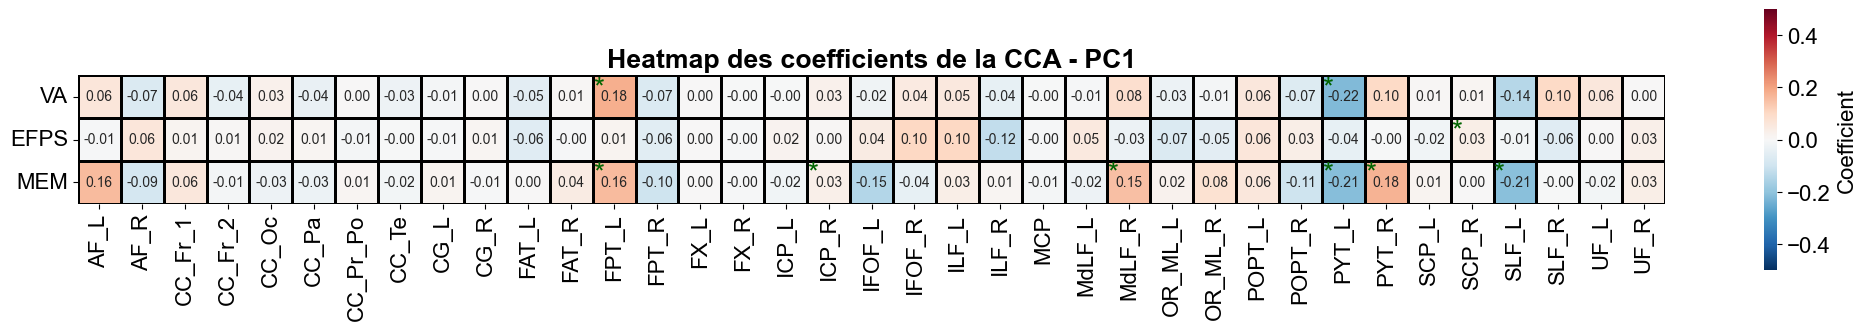

In [31]:
# Heatmap des coefficients de la CCA1

plotting_parameters1 = {
    "data" : coef_df1.T,
    "cmap" : "RdBu_r",
    "vmin" : -0.5,
    "vmax" : 0.5,
    "center" : 0,
    "annot" : True,
    "annot_kws" : {"fontsize": 10},
    "fmt" : ".2f",
    "robust" : True,
    "linewidths" : 0.8,
    "linecolor" : "black",
    "cbar_kws" : {"label": "Coefficient", "shrink": 0.4},
    "square" : True,
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 16, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ) :
        fig, ax = plt.subplots(figsize=(21, 7))
        heatmap = sns.heatmap(ax=ax, **plotting_parameters1)

        ax.set_xlabel("")
        ax.set_title("Heatmap des coefficients de la CCA - PC1")

        for i, j in product(range(coef_pval_df1.T.shape[0]), range(coef_pval_df1.T.shape[1])):
            if coef_pval_df1.T.iloc[i, j] < 0.05:
                ax.text(j, i, "*", ha="left", va="top", color="darkgreen", fontsize=20)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/cca1_coef_heatmap.png", dpi=900)
        plt.show()

Avec principal component 2 : Complexité

In [32]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)
pc2_cols = [col for col in bundles_cols if str(col).startswith("('PC2',")]
X2 = ping_bundles_resid.loc[:, pc2_cols]
X2.index = ping_bundles_resid.index

Y2 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y2.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X2_c, Y2_c = cca.fit_transform(X2, Y2)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X2_c[:, i], Y2_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")


Dimension canonique 1 : r = 0.376
Dimension canonique 2 : r = 0.337
Dimension canonique 3 : r = 0.293


In [33]:
# Performing permutation testing
mod2, score2, coef2, perm_score2, score_pval2, perm_coef2, coef_pval2 = permutation_testing(
    cca,
    X2,
    Y2,
    nb_permutations=5000,
    processes=4,
    verbose= True,
    scoring="r2",
    splits=10
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    7.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   14.0s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   25.2s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:   40.8s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:  2.5min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:  3.4min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:  4.6min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:  5.6min
[Parallel(n_jobs=4)]: Done 5000 out of 5000 | elapsed:  5.6min finished


In [34]:
coef_df2 = pd.DataFrame(
    cca.coef_.T,
    columns=[f"coef{i+1}" for i in range(cca.coef_.T.shape[1])]
)
coef_df2["varname"] = vars
coef_df2.to_excel(f"{output_dir}/cca2_coef.xlsx", index=False, header=True)

coef_pval_df2 = pd.DataFrame(coef_pval2, index=bundle_labels, columns=Y2.columns)


# Control for false discovery rate
coef_pval_corr2 = pd.DataFrame()
for col in coef_pval_df2.columns:
    coef_pval_corr2[f"{col}_fdr_corrected"] = false_discovery_control(coef_pval_df2[col], method="bh")
coef_pval_corr2.index = coef_pval_df2.index

coef_pval_df2.to_excel(f"{output_dir}/cca2_coef_pval.xlsx", index=True, header=True)
coef_pval_corr2.to_excel(f"{output_dir}/cca2_coef_pval_fdr_corrected.xlsx", index=True, header=True)

In [35]:
# Générer les plots pour chaque variable cognitive
for i in range(0, Y2.shape[1]):
    generate_coef_plot(
        coef_df2,
        coef_pval_corr2.values[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/cca2_coef_{i+1}.png"
    )

In [5]:
# Loadings X2

In [ ]:
# Loadings Y2

In [36]:
coef_df2.set_index("varname", inplace=True)
coef_df2.columns = ["VA", "EFPS", "MEM"]

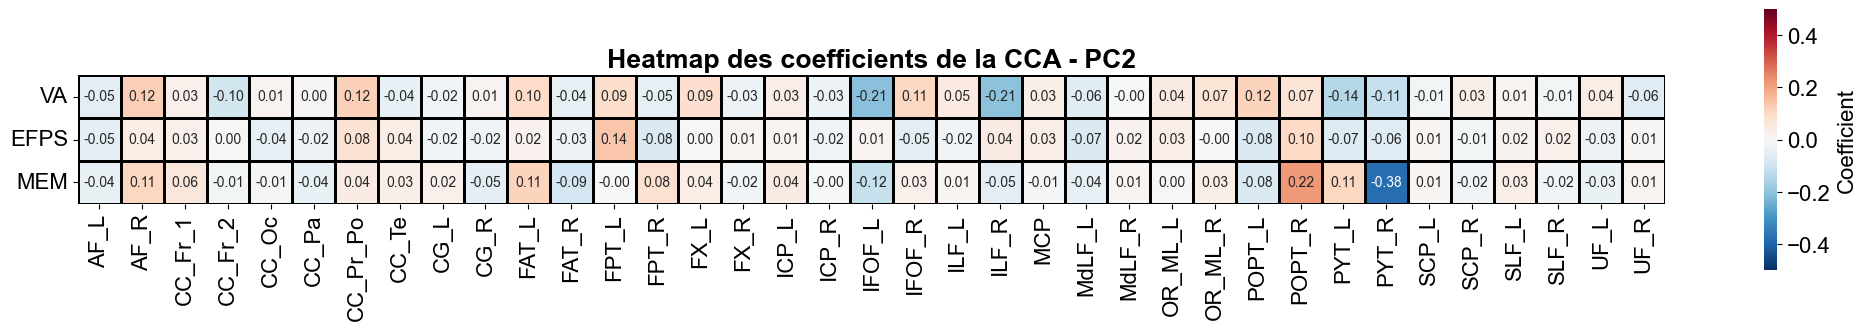

In [38]:
# Heatmap des coefficients de la CCA (PC2)

plotting_parameters2 = {
    "data" : coef_df2.T,
    "cmap" : "RdBu_r",
    "vmin" : -0.5,
    "vmax" : 0.5,
    "center" : 0,
    "annot" : True,
    "annot_kws" : {"fontsize": 10},
    "fmt" : ".2f",
    "robust" : True,
    "linewidths" : 0.8,
    "linecolor" : "black",
    "cbar_kws" : {"label": "Coefficient", "shrink": 0.4},
    "square" : True,
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 16, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ) :
        fig, ax = plt.subplots(figsize=(21, 7))
        heatmap = sns.heatmap(ax=ax, **plotting_parameters2)

        ax.set_xlabel("")
        ax.set_title("Heatmap des coefficients de la CCA - PC2")

        for i, j in product(range(coef_pval_corr2.T.shape[0]), range(coef_pval_corr2.T.shape[1])):
            if coef_pval_corr2.T.iloc[i, j] < 0.05:
                ax.text(j, i, "*", ha="left", va="top", color="darkgreen", fontsize=20)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/cca2_coef_heatmap.png", dpi=900)
        plt.show()

Avec principal component 3 : Densité axonal

In [39]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)
pc3_cols = [col for col in bundles_cols if str(col).startswith("('PC3',")]
X3 = ping_bundles_resid.loc[:, pc3_cols]
X3.index = ping_bundles_resid.index

Y3 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y3.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X3_c, Y3_c = cca.fit_transform(X3, Y3)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X3_c[:, i], Y3_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")


Dimension canonique 1 : r = 0.363
Dimension canonique 2 : r = 0.341
Dimension canonique 3 : r = 0.271


In [40]:
# Performing permutation testing
mod3, score3, coef3, perm_score3, score_pval3, perm_coef3, coef_pval3 = permutation_testing(
    cca,
    X3,
    Y3,
    nb_permutations=5000,
    processes=4,
    verbose= True,
    scoring="r2",
    splits=10
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   13.2s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   24.8s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   43.2s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  1.9min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  2.5min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:  3.4min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:  4.7min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:  6.3min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:  8.0min
[Parallel(n_jobs=4)]: Done 5000 out of 5000 | elapsed:  8.0min finished


In [ ]:
#  A SUPPRIMER
# Exporter les coefficients et les p-values dans des fichiers Excel
coef_df3.to_excel(f"{output_dir}/CCA3/cca3_coef.xlsx", index=False, header=True)

coef_pval_df3 = pd.DataFrame(coef_pval3, index=bundle_labels, columns=["VA", "EFPS", "MEM"])
coef_pval_df3.to_excel(f"{output_dir}/cca3_coef_pval.xlsx", index=True, header=True)

In [41]:
coef_df3 = pd.DataFrame(
    cca.coef_.T,
    columns=[f"coef{i+1}" for i in range(cca.coef_.T.shape[1])]
)
coef_df3["varname"] = vars
coef_df3.to_excel(f"{output_dir}/cca3_coef.xlsx", index=False, header=True)

coef_pval_df3 = pd.DataFrame(coef_pval3, index=bundle_labels, columns=Y3.columns)


# Control for false discovery rate
coef_pval_corr3 = pd.DataFrame()
for col in coef_pval_df2.columns:
    coef_pval_corr3[f"{col}_fdr_corrected"] = false_discovery_control(coef_pval_df3[col], method="bh")
coef_pval_corr3.index = coef_pval_df3.index

coef_pval_df3.to_excel(f"{output_dir}/cca3_coef_pval.xlsx", index=True, header=True)
coef_pval_corr3.to_excel(f"{output_dir}/cca3_coef_pval_fdr_corrected.xlsx", index=True, header=True)

In [ ]:
# A SUPPRIMER
# Générer les plots pour chaque composante canonique
for i in range(Y3.shape[1]):
    generate_coef_plot(
        coef_df3,
        coef_pval3[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/cca3_coef_{i+1}.png"
    )

In [42]:
# Générer les plots pour chaque variable cognitive
for i in range(0, Y3.shape[1]):
    generate_coef_plot(
        coef_df3,
        coef_pval_corr3.values[:, i],
        coefname = f"coef{i+1}",
        varname = "varname",
        output=f"{output_dir}/cca3_coef_{i+1}.png"
    )

In [ ]:
# Loading X3

In [ ]:
# Loadings Y3

In [43]:
coef_df3.set_index("varname", inplace=True)
coef_df3.columns = ["VA", "EFPS", "MEM"]

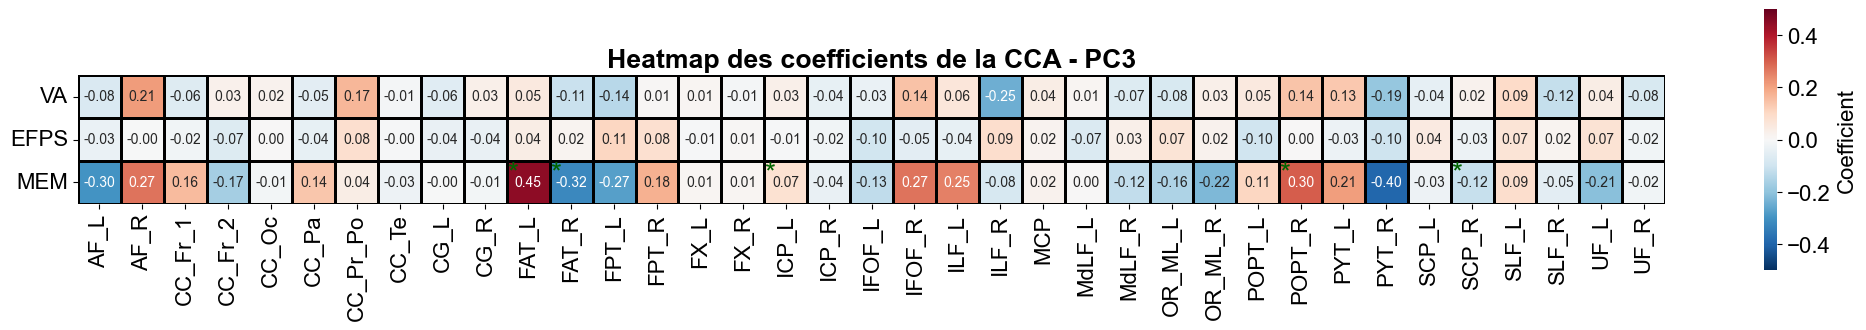

In [44]:
# Heatmap des coefficients de la CCA (PC3)

plotting_parameters3 = {
    "data" : coef_df3.T,
    "cmap" : "RdBu_r",
    "vmin" : -0.5,
    "vmax" : 0.5,
    "center" : 0,
    "annot" : True,
    "annot_kws" : {"fontsize": 10},
    "fmt" : ".2f",
    "robust" : True,
    "linewidths" : 0.8,
    "linecolor" : "black",
    "cbar_kws" : {"label": "Coefficient", "shrink": 0.4},
    "square" : True,
}

with plt.rc_context(
        {"font.family" : "Arial",
        "font.size" : 16, "font.weight" : "normal", "axes.titleweight" : "bold",
        }
    ) :
        fig, ax = plt.subplots(figsize=(21, 7))
        heatmap = sns.heatmap(ax=ax, **plotting_parameters3)

        ax.set_xlabel("")
        ax.set_title("Heatmap des coefficients de la CCA - PC3")

        for i, j in product(range(coef_pval_df3.T.shape[0]), range(coef_pval_df3.T.shape[1])):
            if coef_pval_df3.T.iloc[i, j] < 0.05:
                ax.text(j, i, "*", ha="left", va="top", color="darkgreen", fontsize=20)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/cca3_coef_heatmap.png", dpi=900)
        plt.show()